# simplex demo

In [2]:
# import Python packages
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.svm import SVC

In [7]:
%matplotlib inline

In [3]:
# import bespoke simplex module
from simplex import SimplexColormap, plot_decision_regions, simplex_legend

In [ ]:
# construct 3-class toy problem in 2D
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0,
                           n_informative=2, n_classes=3, n_clusters_per_class=1,
                           class_sep=1.3, random_state=3)
clf = SVC(probability=True, gamma=1.0).fit(X, y)

In [8]:
# red / green / blue triad
cmap = SimplexColormap(sharpen=1.0)
pad = 1.0
xlim = (X[:,0].min()-pad, X[:,0].max()+pad)
ylim = (X[:,1].min()-pad, X[:,1].max()+pad)

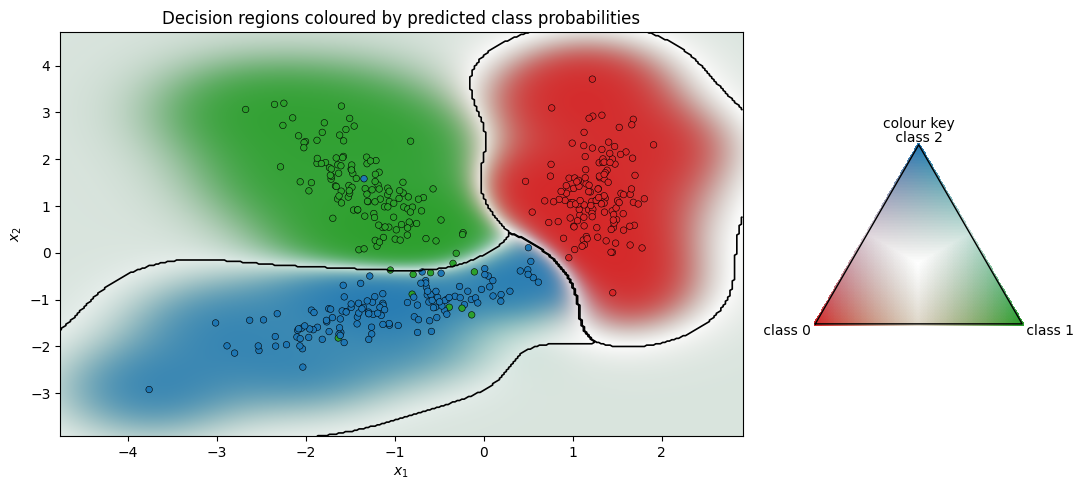

In [9]:
fig, (ax, axL) = plt.subplots(1, 2, figsize=(11, 5),
                              gridspec_kw={"width_ratios":[3,1]})

plot_decision_regions(clf, xlim, ylim, ax=ax, cmap=cmap, n=300)

# overlay the training points using the same colour map at full confidence
onehot = np.eye(3)[y]
ax.scatter(X[:,0], X[:,1], c=cmap(onehot), edgecolors="k", linewidths=0.4, s=22)

ax.set_title("Decision regions coloured by predicted class probabilities")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

simplex_legend(ax=axL, cmap=cmap)
axL.set_title("colour key", fontsize=10)

plt.tight_layout()
plt.show()